# Introduction to Regression with Neural Network in TensorFlow

There are many definition for a regression problem but in our case, we're going to
siimplify it: predicting a numerical variable based on some other combination of variables, even shjorter... predicting a number.

> **Architecture**

  - InputLayer shape -> Same shape as input features
  - Hidden Layer(s) -> Problem specific min=1, max=unlimited
  - Neurons per hidden_layer -> problem specific; generally 10-100
  - Output Layer Shape -> Same shape as desired prediction shape
  - Hidden Activation -> Usually ReLU
  - Output Activation -> None, ReLU, logistic/tanh
  - Loss function -> MSE, MAE
  - Optimizer -> SGD, Adam

In [1]:
# Import tensorflow
import tensorflow as tf
print(tf.__version__)

2026-05-17 16:23:31.953311: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.16.2


# Craeting data to view and fit

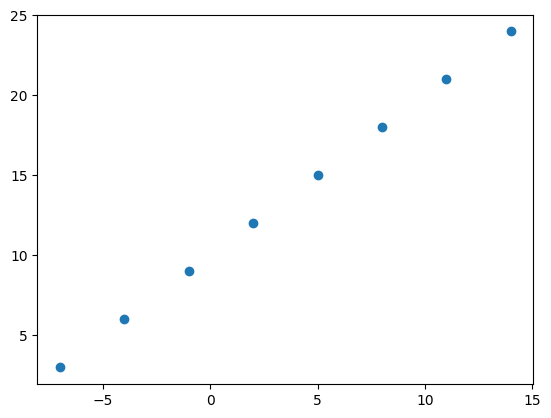

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Create Features
X = np.array([-7., -4., -1., 2., 5., 8., 11., 14.])

# Create labels
y = np.array([3., 6., 9., 12., 15., 18., 21., 24.])

# Visualize
plt.scatter(X, y)

## Input and output shapes

In [3]:
## demo tensors for Housing price
house_info = tf.constant(['bedroom', 'bathroom', 'garages'])
house_price = tf.constant([939700])

house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garages'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [4]:
X[0], y[0]

(-7.0, 3.0)

In [5]:
X[1], y[1]

(-4.0, 6.0)

In [ ]:
input_shape = X.shape
output_shape = y.shape

input_shape, output_shape

## Steps in modelling with TensorFlow

1. **Creating a Model** - define the inpur and output layers, as we as the hidden layers of a deep learning model.
2. **Compile a Model** - define the loss function(in other words, the function which tells our model how wrong it is) and the optimizer (tells our model how to improve the patterns its learnibg) and evaluation matrix (what we can use to interpret the performance of our model).
3. **Fitting a Model** - letting the model try to find the pattern between X and y(features and labels)

In [7]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model using Sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae, # mae is Mean Absolute Error
              optimizer=tf.keras.optimizers.SGD(), # SGD is Stochastic Gradient Descent
              metrics=["mae"]
              )

# fit the model
model.fit(tf.expand_dims(X, axis=-1), y, epochs=5) # reshaping the dimension of X .., structuring them

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - loss: 10.3978 - mae: 10.3978
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 10.2653 - mae: 10.2653
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 10.1328 - mae: 10.1328
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 10.0003 - mae: 10.0003
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 9.8678 - mae: 9.8678


In [8]:
# check out X and y
X, y

(array([-7., -4., -1.,  2.,  5.,  8., 11., 14.]),
 array([ 3.,  6.,  9., 12., 15., 18., 21., 24.]))

In [9]:
# try making prediction using our model
y_pred = model.predict(tf.cast([17.0, 19.0, -4.6, -7.0], dtype='float'))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


array([[18.092728],
       [20.215403],
       [-4.83215 ],
       [-7.379359]], dtype=float32)

In [10]:
y_pred +11.0637

array([[29.156427 ],
       [31.279102 ],
       [ 6.2315497],
       [ 3.684341 ]], dtype=float32)

## Improving our model

We can improve our model, by altering the steps we took to crate our model.

1. **Creating a model** - here we might ass more layers, increase the number of hidden units (all called neurons) within each of the hidden layers, change the activation function of each layer.
2. **Compiling a model** - here we might change the optimization function or perhaps the **learning rate** of the optimization function.
3. **Fitting a mdoel** - here we might fit our model for more epochs (leave it training for longer) or on more data (give the model more examplke to learn from)

In [11]:
# lets rebuild the model

# 1. Create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=['mae'])

# fit the model (this time trian for lobger)
model.fit(tf.expand_dims(X, axis=-1), y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - loss: 11.8829 - mae: 11.8829
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 11.7504 - mae: 11.7504
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 11.6179 - mae: 11.6179
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 11.4854 - mae: 11.4854
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 11.3529 - mae: 11.3529
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 11.2204 - mae: 11.2204
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 11.0879 - mae: 11.0879
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 10.9554 - mae: 10.9554
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 10.8229 - mae: 10.8229
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 10.6904 - mae: 10.6904
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 10.5579 - mae: 10.5579
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 10.4254 - mae: 10.4254
Epoch 13/100
1/1 ━━━━━━━

In [12]:
# try making prediction using improved model
y_pred = model.predict(tf.cast([17.0, 19.0, -4.6, -7.0], dtype='float'))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


array([[ 30.11433 ],
       [ 33.55837 ],
       [ -7.08129 ],
       [-11.214137]], dtype=float32)

In [13]:
# lets make another chang in the model again to improve it
## this time with extra hidden layer with 100 hidden units

# 1. Create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=['mae'])

# fit the model (this time trian for lobger)
model.fit(tf.expand_dims(X, axis=-1), y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - loss: 14.0261 - mae: 14.0261
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 13.4788 - mae: 13.4788
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 12.9367 - mae: 12.9367
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 12.3896 - mae: 12.3896
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 11.8355 - mae: 11.8355
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 11.2734 - mae: 11.2734
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 10.6980 - mae: 10.6980
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 10.0956 - mae: 10.0956
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 9.4738 - mae: 9.4738
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 8.8174 - mae: 8.8174
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 8.1286 - mae: 8.1286
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 7.3999 - mae: 7.3999
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━

In [14]:
# try making prediction using improved model
y_pred = model.predict(tf.cast([17.0, 19.0, -4.6, -7.0], dtype='float'))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


array([[31.79277  ],
       [35.413574 ],
       [ 2.2283168],
       [ 3.050793 ]], dtype=float32)

In [15]:
# make oanothe rchange again
# lets rebuild the model

# 1. Create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation=None),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),   # learninf_rate is one of the most important HYPERPARAMETER
              metrics=['mae'])

# fit the model (this time trian for lobger)
model.fit(tf.expand_dims(X, axis=-1), y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step - loss: 12.2130 - mae: 12.2130
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 11.1975 - mae: 11.1975
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 10.1790 - mae: 10.1790
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 9.1486 - mae: 9.1486
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 8.0977 - mae: 8.0977
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 7.0184 - mae: 7.0184
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 7.1151 - mae: 7.1151
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 7.5384 - mae: 7.5384
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 7.9770 - mae: 7.9770
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 8.0081 - mae: 8.0081
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 7.7445 - mae: 7.7445
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 7.2786 - mae: 7.2786
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4

In [16]:
# try making prediction using improved model
y_pred = model.predict(tf.cast([17.0, 19.0, -4.6, -7.0], dtype='float'))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


array([[27.009768 ],
       [29.00854  ],
       [ 5.4230576],
       [ 3.024534 ]], dtype=float32)

## Evaluating the model

In Practice, a typical workflow you'll go through when buiding a neural network is:

```
Build a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it ...
```

when building a model ... there are 3 words to remember
> ``` EXPERIMENT EXPERIMENT EXPERIMENT```

when evaluating a model ... there are 3 words to remember
> ```VISUALIZE VISUALIZE VISUALIZE```

It;s a good idea to visualize
* The data - what data are we working with? What does it look like?
* The model itself - what does our model look like?
* The training of a model - how does a model perform while it learns?
* The predictions of the model - how do the predictions of a model line up against the ground truth (the original label)?

In [17]:
# make a bigger dataset
X = tf.range(-100, 100, 4)
X

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [18]:
## make labeld for dastset
y = X + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

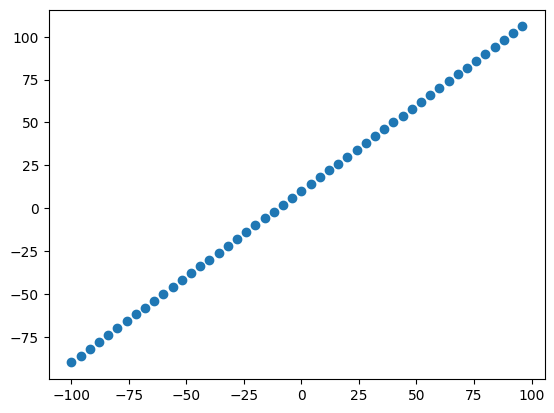

In [19]:
# Visualise the datset
plt.scatter(X, y);

### The concept of three sets...

* Trainig set - model learn from this data, which is typically 70-80% of the data available.
* Validation set - the model gets tuned on this data, which is typically 10-15% of the data available.
* Test set - the model gets evaluated on this data to test what it has learnt, which is typically 10-15% of the data available.


In [20]:
# check the length of samples
len(X)

50

In [21]:
# split the data into train and test set
X_train = X[:40]  # first 40 are training smaples (80% of the data)
y_train = y[:40]

X_test = X[40:]   # last 40 are testing samples (20% of the data)
y_test = y[40:]

len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

In [22]:
# visualize the data
# train test

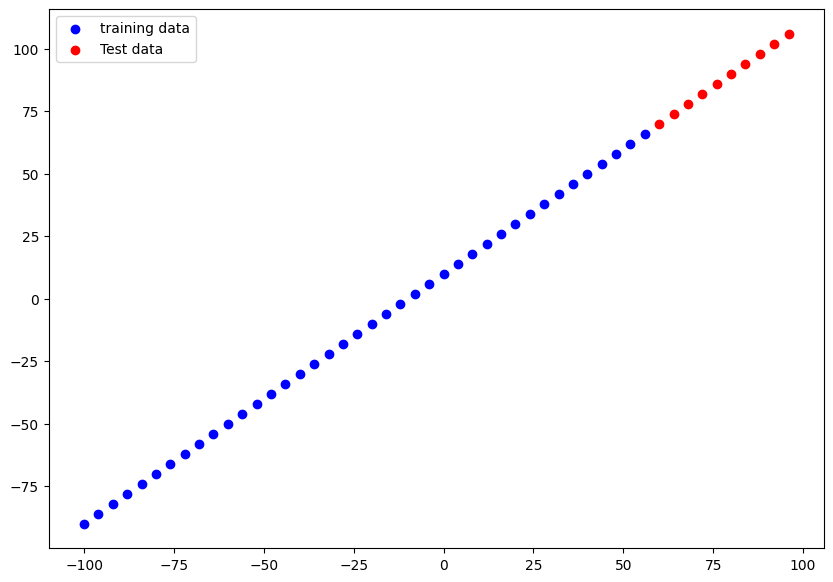

In [23]:
plt.figure(figsize=(10,7))
# plot train data
plt.scatter(X_train, y_train, c='b', label='training data')  # model will learn on this data
# plot test data
plt.scatter(X_test, y_test, c='r', label='Test data')  # want our model to predict this given X -> y
plt.legend()
plt.show()

In [24]:
import tensorflow as tf

# lets build neural network for our data

# 1. create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=['mae'])

# 3. fit the model
#model.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=100) # Corrected arguments

In [25]:
# visulaising the model
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
## lets create a model which will automatocally by definig the input shapeargument
tf.random.set_seed(42)

# 1. creating a moedel
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, input_shape=[1], name='input_layer'),
    tf.keras.layers.Dense(1, name='output_layer')
], name='model_1')

# 2. compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['mae'])

/Users/spy/Desktop/dl-journey/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301 (1.18 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

* total params - total number of parameters in the model to learn
* trainable parameters - these are the parameters (patterns) model can update as it trains
* Non-trainable parameter - these parameters aren't updated during training (this is typical when we bring in already learn patterns or parameters from other models durinf **transfer learning**)

In [28]:
model.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=200, verbose=2)

Epoch 1/200
2/2 - 1s - 411ms/step - loss: 48.9350 - mae: 48.9350
Epoch 2/200
2/2 - 0s - 30ms/step - loss: 46.7110 - mae: 46.7110
Epoch 3/200
2/2 - 0s - 26ms/step - loss: 44.4921 - mae: 44.4921
Epoch 4/200
2/2 - 0s - 22ms/step - loss: 42.2756 - mae: 42.2756
Epoch 5/200
2/2 - 0s - 20ms/step - loss: 40.0610 - mae: 40.0610
Epoch 6/200
2/2 - 0s - 20ms/step - loss: 37.8480 - mae: 37.8480
Epoch 7/200
2/2 - 0s - 20ms/step - loss: 35.6360 - mae: 35.6360
Epoch 8/200
2/2 - 0s - 20ms/step - loss: 33.4346 - mae: 33.4346
Epoch 9/200
2/2 - 0s - 20ms/step - loss: 31.2568 - mae: 31.2568
Epoch 10/200
2/2 - 0s - 20ms/step - loss: 29.0788 - mae: 29.0788
Epoch 11/200
2/2 - 0s - 20ms/step - loss: 26.8992 - mae: 26.8992
Epoch 12/200
2/2 - 0s - 21ms/step - loss: 24.7316 - mae: 24.7316
Epoch 13/200
2/2 - 0s - 21ms/step - loss: 22.5908 - mae: 22.5908
Epoch 14/200
2/2 - 0s - 22ms/step - loss: 20.4700 - mae: 20.4700
Epoch 15/200
2/2 - 0s - 22ms/step - loss: 18.3850 - mae: 18.3850
Epoch 16/200
2/2 - 0s - 26ms/step

The `plot_model` function requires the `pydot` and `graphviz` libraries to be installed. Let's install them.

In [29]:
!pip install pydot

In [30]:
!pip install graphviz

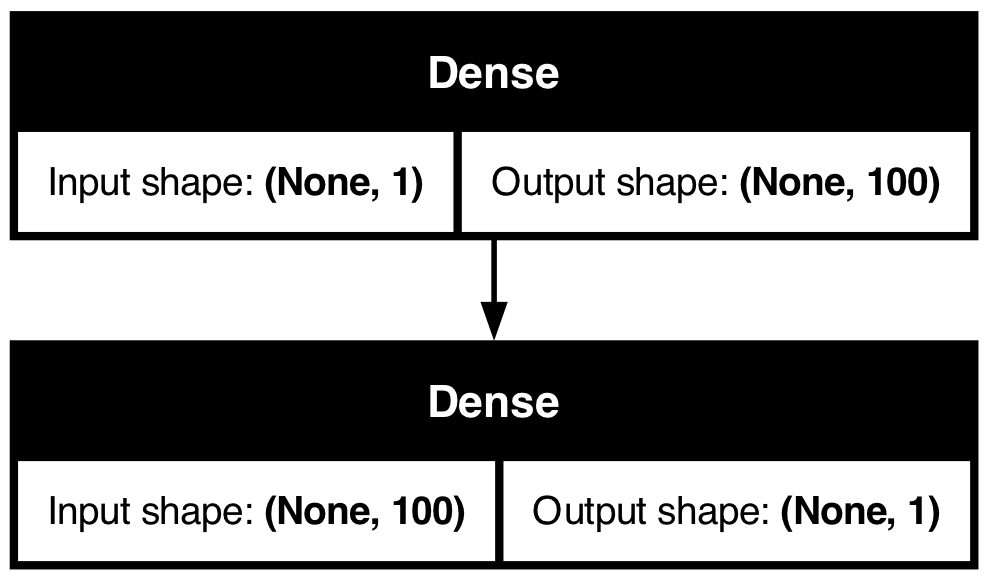

In [31]:
# Install TensorFlow if not already installed
from tensorflow.keras.utils import plot_model

plot_model(model=model, show_shapes=True)

In [32]:
## visualising our model predictions
y_pred = model.predict(X_test)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


array([[ 66.458466],
       [ 70.35909 ],
       [ 74.25975 ],
       [ 78.1604  ],
       [ 82.061035],
       [ 85.96169 ],
       [ 89.86233 ],
       [ 93.76298 ],
       [ 97.66363 ],
       [101.56427 ]], dtype=float32)

In [33]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

In [34]:
## creat a plotting function
def plot_prediction(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=y_pred):
    """
      PLot training data, test data and compares predictions to ground truth labels.
    """

    plt.figure(figsize=(10,7))
    # plot train data
    plt.scatter(train_data, train_labels, c='b', label='training data')  # model will learn on this data
    # plot test data
    plt.scatter(test_data, test_labels, c='g', label='Test data')  # want our model to predict this given X -> y
    # plot model predictions
    plt.scatter(test_data, predictions, c='r', label='Predictions')
    plt.legend()
    plt.show()

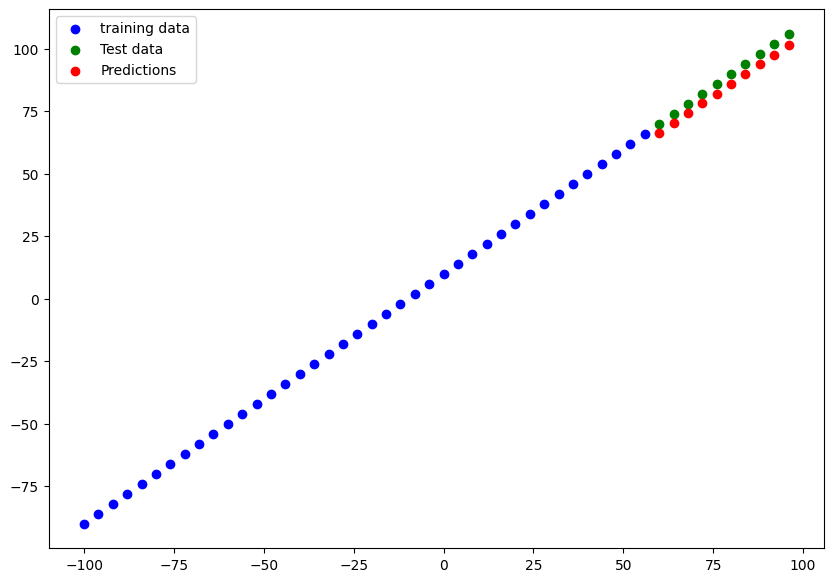

In [35]:
plot_prediction(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=y_pred)

### Evaluating our model's predictions with regrersssion evaluation metrics

> **Some common regression metrics**

* MSE
* MAE
* Huber

In [36]:
## evaluate the model on the test
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 3.9886 - mae: 3.9886


[3.988636016845703, 3.988636016845703]

In [37]:
# claculate the mean absolute error
mae = tf.metrics.mae(y_true=y_test,
                     y_pred=y_pred)

mae

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([3.5415344, 3.6409073, 3.7402496, 3.8395996, 3.9389648, 4.038307 ,
       4.1376724, 4.2370224, 4.3363724, 4.43573  ], dtype=float32)>

In [38]:
# means squared error
mse = tf.keras.losses.mse(y_true=y_test, 
                          y_pred=y_pred)

mse

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([12.542466, 13.256206, 13.989468, 14.742525, 15.515444, 16.307924,
       17.120333, 17.952358, 18.804125, 19.675701], dtype=float32)>

In [39]:
# mse -V2.0
mse = tf.metrics.mse(y_true=y_test,
                     y_pred=y_pred)

mse

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([12.542466, 13.256206, 13.989468, 14.742525, 15.515444, 16.307924,
       17.120333, 17.952358, 18.804125, 19.675701], dtype=float32)>

In [40]:
# Huber
'''Huber Loss acts as a hybrid: It behaves like MSE when the error is small, 
and like MAE when the error is large.'''
huber = tf.metrics.huber(y_true=y_test,
                         y_pred=y_pred)

huber

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([3.0415344, 3.1409073, 3.2402496, 3.3395996, 3.4389648, 3.5383072,
       3.6376724, 3.7370224, 3.8363724, 3.93573  ], dtype=float32)>

In [41]:
# make some functions to reuse MAE and MSE
def mae(y_true, y_pred):
    return tf.metrics.mae(y_true=y_true,
                          y_pred=tf.squeeze(y_pred))
    
def mse(y_true, y_pred):
    return tf.metrics.mse(y_true=y_true,
                          y_pred=tf.squeeze(y_pred))

### Running experiments to improve our 

```
Build a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it ...
```

1. Get more data - get more example for your model to train on (more opportunities to learn patterns or relatinships between featueres and labels).
2. Make our model lager (using a more comoplex model) - this might come in the form of more layers or more hidden units in each layer.
3. Train for longer - give model more of a chance to find patterns in data.

Let's do 3 modelling experiments

1. `model_1` - same as the original model, 1 layer trained for 100 epochs
2. `model_2` - 2 layers, trained for 100 epochs
3. `model_3` - 2 layerd, trianed for 500 epochs

**Build `model_1`**

In [42]:
# set the random seed for reproducible results
tf.random.set_seed(42)

# 1. build the model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. compile the model
model_1.compile(loss=tf.keras.losses.mae,
           optimizer=tf.keras.optimizers.SGD(),
           metrics=['mae'])

# 3. fit the model
model_1.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 17.7544 - mae: 17.7544 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 11.9481 - mae: 11.9481
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8.2139 - mae: 8.2139
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 9.9190 - mae: 9.9190
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8.1952 - mae: 8.1952
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 9.9061 - mae: 9.9061
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8.1765 - mae: 8.1765
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 9.8931 - mae: 9.8931
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8.3462 - mae: 8.3462
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 8.8600 - mae: 8.8600
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 8.7486 - mae: 8.7486
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 8.4820 - mae: 8.4820
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19m

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


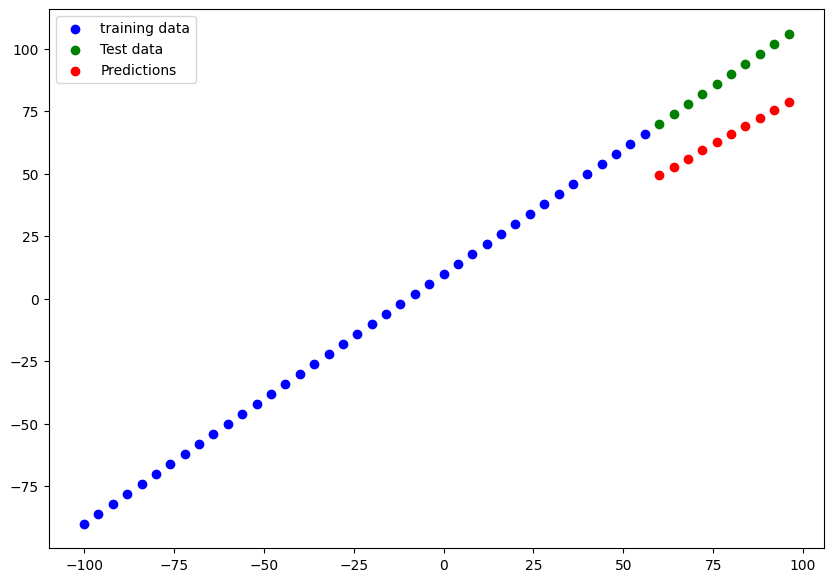

In [43]:
# make and plot prediction
y_pred_1 = model_1.predict(X_test)
plot_prediction(predictions=y_pred_1)

In [44]:
## calculate model_1 evaluation metrics
mae_1 = mae(y_test, y_pred_1)
mse_1 = mse(y_test, y_pred_1)

mae_1, mse_1

(<tf.Tensor: shape=(), dtype=float32, numpy=23.861855>,
 <tf.Tensor: shape=(), dtype=float32, numpy=574.452>)

**Build `model_2`**

Build with 2 Dnese layer for 100 Epochs

In [45]:
# setting random seed
tf.random.set_seed(42)

# 1. create a model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# compile the model
model_2.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mse'])

# fit the model
model_2.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 27.0401 - mse: 1100.6472
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 23.6253 - mse: 780.4948
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 22.3409 - mse: 683.8954
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 14.6050 - mse: 346.6239
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 18.7201 - mse: 471.1492
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 13.6804 - mse: 288.1316
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 15.2759 - mse: 328.8784
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 15.7712 - mse: 338.1594
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 12.3172 - mse: 241.9145
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 14.8575 - mse: 309.7718
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 15.6702 - mse: 331.1756
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 12.4123 - mse: 237.1343
Epoch 13/100

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


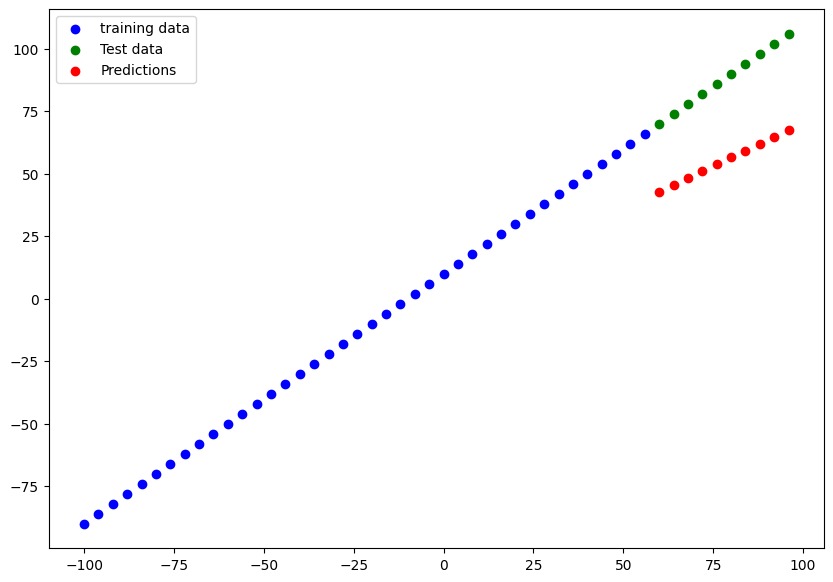

In [46]:
# make and plot prediction
y_pred_2 = model_2.predict(X_test)
plot_prediction(predictions=y_pred_2)

In [47]:
## calculate model_2 evaluation metrics
mae_2 = mae(y_test, y_pred_2)
mse_2 = mse(y_test, y_pred_2)

mae_2, mse_2

(<tf.Tensor: shape=(), dtype=float32, numpy=32.824554>,
 <tf.Tensor: shape=(), dtype=float32, numpy=1090.4402>)

**Build `model_3`**

* 2 layers for 500 epochs

In [48]:
# setting random seed
tf.random.set_seed(42)

# 1. create a model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# compile the model
model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mse'])

# fit the model
model_3.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=500)

Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 37.5526 - mse: 2006.5322 
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 25.7758 - mse: 917.0939
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 23.5353 - mse: 762.4892
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 15.4101 - mse: 373.3524
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 18.5856 - mse: 464.2090
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 13.6372 - mse: 286.3885
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 15.2482 - mse: 327.5942
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 15.7663 - mse: 337.7258
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 12.3270 - mse: 241.6228
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 14.8706 - mse: 309.9661
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 11.4360 - mse: 217.8948
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 14.7574 - mse: 305.5921
Epoch 13/50

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


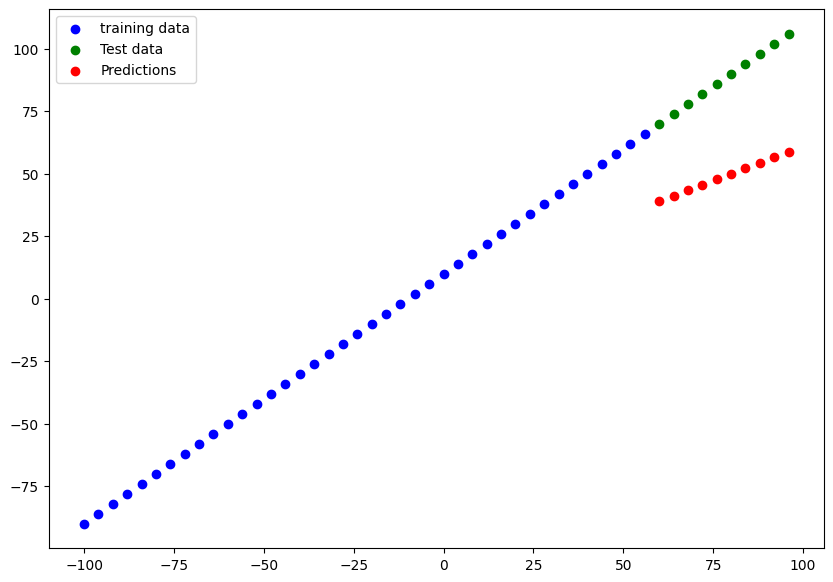

In [49]:
# make and plot prediction
y_pred_3 = model_3.predict(X_test)
plot_prediction(predictions=y_pred_3)

In [50]:
## calculate model_2 evaluation metrics
mae_3 = mae(y_test, y_pred_3)
mse_3 = mse(y_test, y_pred_3)

mae_3, mse_3

(<tf.Tensor: shape=(), dtype=float32, numpy=39.007996>,
 <tf.Tensor: shape=(), dtype=float32, numpy=1548.5159>)

In [51]:
## lets compare our model with pandas dataframe
import pandas as pd

model_results = [['model_1', mae_1.numpy(), mse_1.numpy()],
                 ['model_2', mae_2.numpy(), mse_2.numpy()],
                 ['model_3', mae_3.numpy(), mse_3.numpy()]]

all_results = pd.DataFrame(model_results, columns=['model', 'mae', 'mse'])

all_results

,model,mae,mse
0,model_1,23.861855,574.452026
1,model_2,32.824554,1090.440186
2,model_3,39.007996,1548.515869


In [52]:
model_1.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

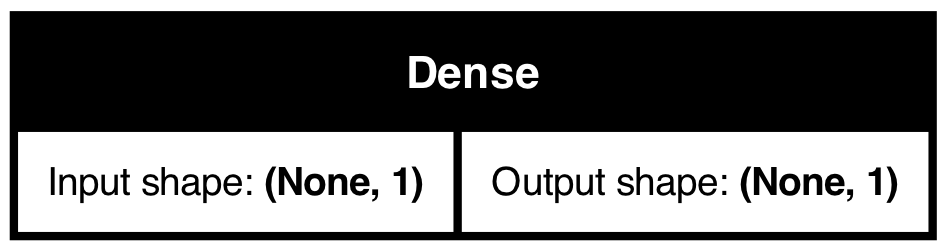

In [53]:
plot_model(model_1, to_file='model.png', show_shapes=True)

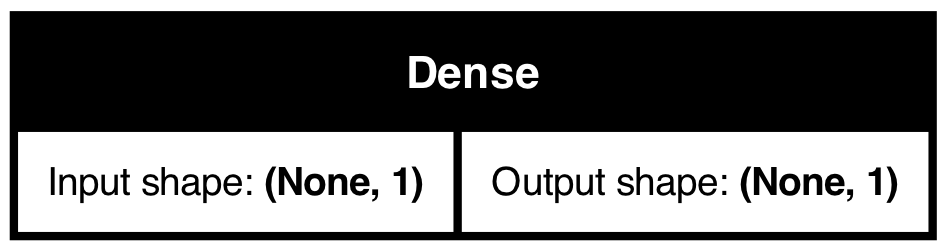

In [54]:
# alternative
from IPython.display import Image
Image('../assets/model.png')

### Tracking your experiments

One really good habit in Machine Learning modelling is to track the results of your experiments.And when doing so , it can be tedious if you're running lots of experiments.

Luckily, there are tools to help us!

📖 **Resources**: As you build more models, you'll want to look into using
* *TensorBoard* - a component of TensorFlow library to help track modelling experiments (we'll se thus later).
* *Weights & Biases* - a tool for tracking all kinds of machine learning experiments (plug straight into TensorBoard).

### Saving our Models

Saving our models alllow us to use them outside of the current run time environment (where they are trained), such as in web application or mobile app.

There are two main formats we can save our mode to:

1. The SaveModel format
2. The HDF5 format

In [55]:
# save model using SaveModel format
model_1.save('../assets/SavedModel_format.keras')

In [56]:
#  save model usig HDF5 format
## recomend good for large file and outside uses
model_1.save('../assets/HDF%_format.h5')

In [57]:
## loading and testing the model
load_SavedModel_format = tf.keras.models.load_model('../assets/SavedModel_format.keras')
load_SavedModel_format.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [58]:
model_1.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [59]:
# comparing the predicting of original model with SavedModel
model_1_preds = model_1.predict(X_test)
load_SavedModel_format_preds = load_SavedModel_format.predict(X_test)

model_1_preds == load_SavedModel_format_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

In [60]:
mae(y_true=y_test, y_pred=model_1_preds) == mae(y_true=y_test, y_pred=load_SavedModel_format_preds)

<tf.Tensor: shape=(), dtype=bool, numpy=True>

In [61]:
model_1_preds

array([[49.66372 ],
       [52.880257],
       [56.096794],
       [59.313335],
       [62.529877],
       [65.746414],
       [68.96295 ],
       [72.1795  ],
       [75.396034],
       [78.61257 ]], dtype=float32)

In [62]:
load_SavedModel_format_preds

array([[49.66372 ],
       [52.880257],
       [56.096794],
       [59.313335],
       [62.529877],
       [65.746414],
       [68.96295 ],
       [72.1795  ],
       [75.396034],
       [78.61257 ]], dtype=float32)

In [63]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

### Downloading files from Google Colab

1. file tab and directly download
2. Use code
3. save it to google drive (by mounting the drive) and then download

In [64]:
# # download a file from google colab
# from google.colab import files
# files.download('file_name')

### A larger example

In [65]:
# import required libraries
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

In [66]:
# read insurance dataset
insurance = pd.read_csv('https://github.com/stedy/Machine-Learning-with-R-datasets/blob/master/insurance.csv?raw=true')
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [67]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [68]:
# encode the categorical data 
#  using pandas get_dummies for OneHotEncoding
insurance_one_hot = pd.get_dummies(insurance, dtype=float)
insurance_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,18,33.770,1,1725.55230,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [69]:
# create X and y values (features and labels)
X = insurance_one_hot.drop('charges', axis=1)
y = insurance_one_hot['charges']

In [70]:
# visualise X
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,18,33.770,1,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,28,33.000,3,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,33,22.705,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,32,28.880,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [71]:
# visualise y
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [72]:
# Create train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, 
                                                    random_state=42)

len(X_train), len(X_test), len(y_train)

(1070, 268, 1070)

In [73]:
# build a neural network for regression

# 1. create a model
insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. compile the models
insurance_model.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.SGD(),
                        metrics=['mae'])

# 3. fit the model
insurance_model.fit(X_train, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 8640.6367 - mae: 8640.6367  
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7724.0923 - mae: 7724.0923
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7572.0439 - mae: 7572.0439
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7661.5874 - mae: 7661.5874
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7338.6548 - mae: 7338.6548
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7541.2983 - mae: 7541.2983
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7635.5132 - mae: 7635.5132
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7729.4727 - mae: 7729.4727
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7713.4663 - mae: 7713.4663
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7440.6899 - mae: 7440.6899
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7487.0176 - mae: 7487.0176
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/ste

In [74]:
# check the results of the insurance model on the test data
insurance_model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8288.5059 - mae: 8288.5059  


[8288.505859375, 8288.505859375]

In [75]:
y_train.median(), y_train.mean()

(9575.4421, 13346.089736364485)

Our model is not performing good lets improve it...

In [76]:
# add an extra layer with more hidden units with Adam optimizer

# set random seed  
tf.random.set_seed(42)

# 1. create a model
insurance_model_2 = tf.keras.Sequential([
    # tf.keras.layers.Dense(100, activation=None), # made the model too big to learn on the data
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. compile the model
insurance_model_2.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.Adam(),
                        metrics=['mae'])

# 3. fit the model
insurance_model_2.fit(X_train, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 13351.0957 - mae: 13351.0957
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13339.8418 - mae: 13339.8418
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13327.5332 - mae: 13327.5332
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13313.5586 - mae: 13313.5586
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13297.3594 - mae: 13297.3594
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13278.4404 - mae: 13278.4404
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13256.3984 - mae: 13256.3984
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13230.8867 - mae: 13230.8867
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13201.5977 - mae: 13201.5977
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13168.2656 - mae: 13168.2656
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13130.6484 - mae: 13130.6484
Epoch 12/100
34/34 ━━━━━━━━━━━

In [77]:
# evaluate our second insurance model
insurance_model_2.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7535.4741 - mae: 7535.4741  


[7535.47412109375, 7535.47412109375]

In [78]:
# add an extra layer with more hidden units with Adam optimizer for longer duration

# set random seed  
tf.random.set_seed(42)

# 1. create a model
insurance_model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100), 
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. compile the model
insurance_model_3.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.Adam(),
                        metrics=['mae'])

# 3. fit the model
history = insurance_model_3.fit(X_train, y_train, epochs=200)

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 13286.5479 - mae: 13286.5479
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13125.1943 - mae: 13125.1943
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12779.3623 - mae: 12779.3623
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12097.0264 - mae: 12097.0264
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10947.3428 - mae: 10947.3428
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9481.9990 - mae: 9481.9990 
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8143.3579 - mae: 8143.3579
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7512.6030 - mae: 7512.6030
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7420.3452 - mae: 7420.3452
Epoch 10/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7397.4927 - mae: 7397.4927
Epoch 11/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7377.5693 - mae: 7377.5693
Epoch 12/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0

In [79]:
# evaluate the third model
insurance_model_3.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3405.9990 - mae: 3405.9990  


[3405.9990234375, 3405.9990234375]

Text(0.5, 1.0, 'Training Loss History')

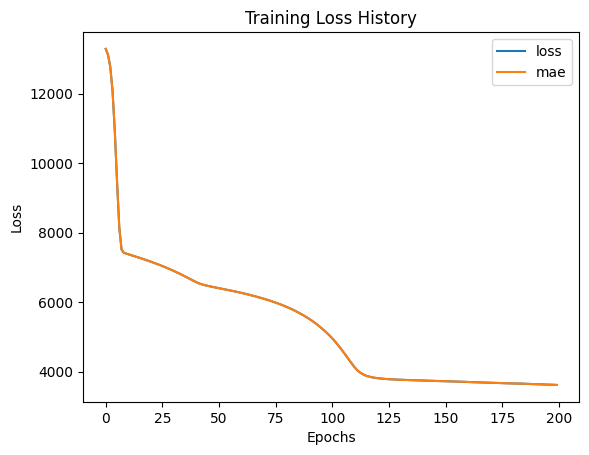

In [80]:
# plot history (also known as loss curve or training curve)
pd.DataFrame(history.history).plot()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss History')

In [81]:
## saving our best model in hf5 format
insurance_model_3.save('best_insurance_model.keras')

In [82]:
# load saved model for making predictions
loaded_model = tf.keras.models.load_model('best_insurance_model.keras')
y_pred = loaded_model.predict(X_test)

# lets create a dataframe to compare the truth with the prediction
compare = pd.DataFrame(data={'truth': y_test, 'prediction': tf.squeeze(y_pred)})
compare

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


,truth,prediction
764,9095.06825,9294.021484
887,5272.17580,6040.969238
890,29330.98315,36133.593750
1293,9301.89355,9287.762695
259,33750.29180,24090.451172
...,...,...
109,47055.53210,35668.652344
575,12222.89830,11688.943359
535,6067.12675,6784.317871
543,63770.42801,34713.910156


> 🤔 **Question** How long should we train for?

It depends. Really... It depends on the problem you're working on. However many people have asked this question before... so TensorFlow had a solution! It is called the [EarlyStoppingCallback], which is TensorFlow component we can add to our model to stop training, once it stopped to improving a certain metric.

### Preprocessing data(Normalization and Standardization)

In terms of scaling values Neural Networks tend to prefer Normalization.

If not sure, try both and observe which performs better.

In [83]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

# read insurance dataset from github
insurance = pd.read_csv('https://github.com/stedy/Machine-Learning-with-R-datasets/blob/master/insurance.csv?raw=true')
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### to prepare data import some libraries from scikit-learn

In [84]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# crearte a colun transformer 
column_transformer = make_column_transformer(
    (MinMaxScaler(), ['age', 'bmi', 'children']),   # encode between 0 and 1
    (OneHotEncoder(handle_unknown='ignore'), ['sex', 'smoker', 'region']) 
)

# create X and y
X = insurance.drop('charges', axis=1)
y = insurance['charges']

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

# fit the column transformer to the training data 
column_transformer.fit(X_train)

# transform the training and test data with normalization and one hot encoding
X_train_normalized = column_transformer.transform(X_train)
X_test_normalized = column_transformer.transform(X_test)

In [85]:
# what does our data look like now
X_train.shape, X_train_normalized.shape

((1070, 6), (1070, 11))

Lets build neural network model on our encoded and normalized data

In [86]:
# create a model

# set random seed
tf.random.set_seed(42)  

# 1. create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),                    
    tf.keras.layers.Dense(1)
])

# 2. compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['mae'])  

# 3. fit the model
model.fit(X_train_normalized, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 13342.3232 - mae: 13342.3232
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13330.6816 - mae: 13330.6816
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13302.6826 - mae: 13302.6826
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13246.9365 - mae: 13246.9365
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13152.5195 - mae: 13152.5195
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13009.2402 - mae: 13009.2402
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12807.1533 - mae: 12807.1533
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12536.5098 - mae: 12536.5098
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12187.9395 - mae: 12187.9395
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11759.8271 - mae: 11759.8271
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 11270.4961 - mae: 11270.4961
Epoch 12/100
34/34 ━━━━━━━━━━━

In [87]:
## evaluate the model on the normalized test data
model.evaluate(X_test_normalized, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3427.4375 - mae: 3427.4375  


[3427.4375, 3427.4375]